## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.
   Samples BM.PB Gender Source tissue.mf cancer  AFFX-BioB-5_at  \
0       39    BM      F   DFCI      BM:f   allB    -1363.276427   
1       40    BM      F   DFCI      BM:f   allB     -796.285053   
2       42    BM      F   DFCI      BM:f   allB     -679.139168   
3       47    BM      M   DFCI      BM:m   allB    -1164.400197   
4       48    BM      F   DFCI      BM:f   allB    -1299.653758   

   AFFX-BioB-M_at  AFFX-BioB-3_at  AFFX-BioC-5_at  ...   U48730_at  \
0    -1058.585495     -541.469194       74.349803  ...  -35.081447   
1    -1167.103365        7.538493       83.544731  ... -404.737767   
2    -1069.832308     -690.301829     -112.075981  ...  193.780934   
3    -1109.939891     -990.127218     -238.574994  ... -256.002292   
4    -1401.998536    -1077.543813     -437.344560  ... -509.203660   

     U58516_at    U73738_at   X06956_at    X16699_at    X83863_at   Z17240_at  

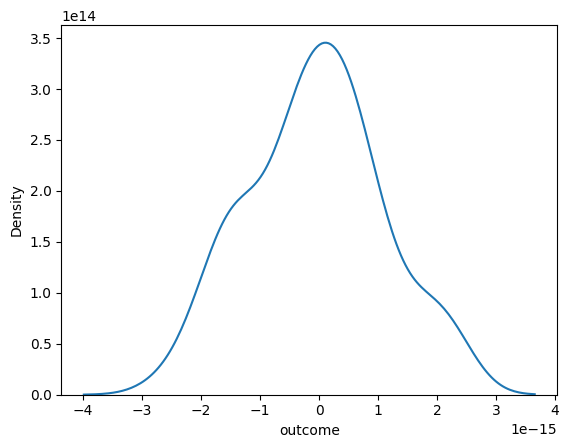

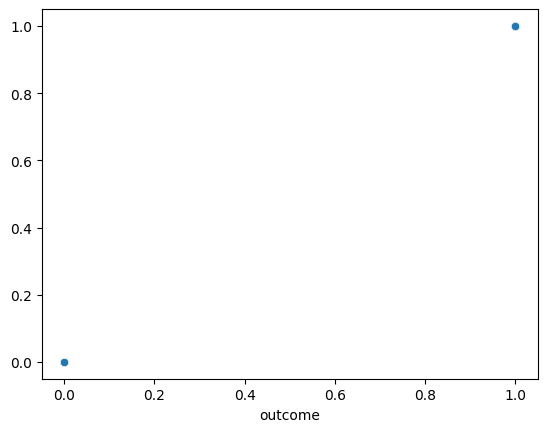

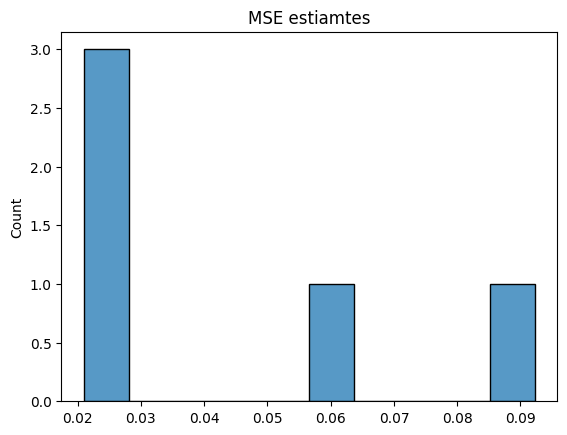

Fold scores: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean score: 0.04336595898622785
Median score: 0.024419803797537328
Std dev: 0.028107820694269984


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.709e-03, tolerance: 1.632e-03
  model = cd_fast.enet_coordinate_descent(


Selected genes:
Index(['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at',
       'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at',
       'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at',
       'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at',
       'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at',
       'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at',
       'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at',
       'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at',
       'K02777_s_at', 

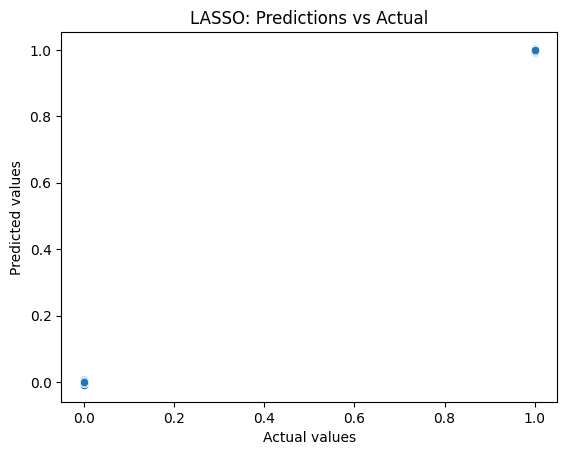

Optimal cost hyperparameter: 0.0006551285568595509


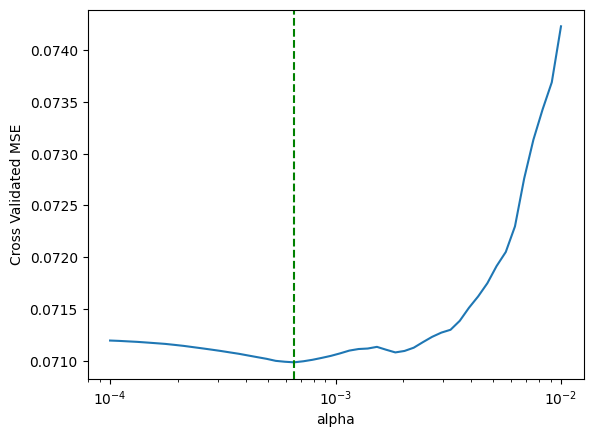

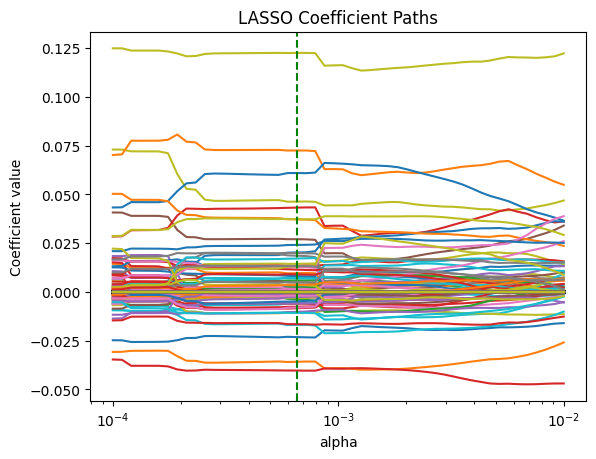

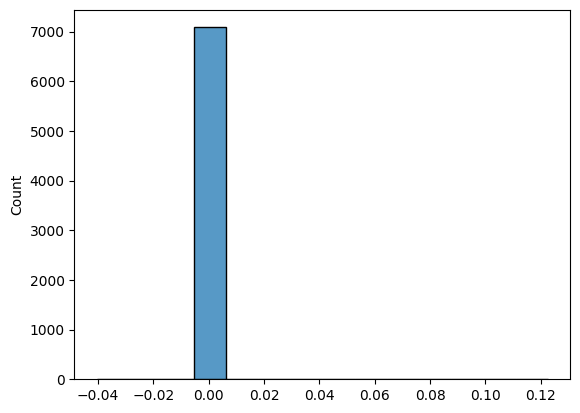

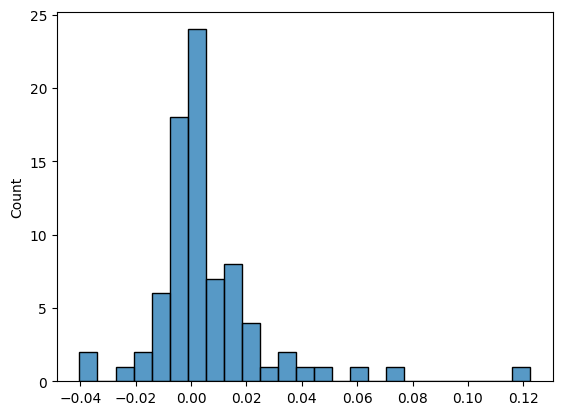

Nonzero coefficients: 80
Total genes: 7129


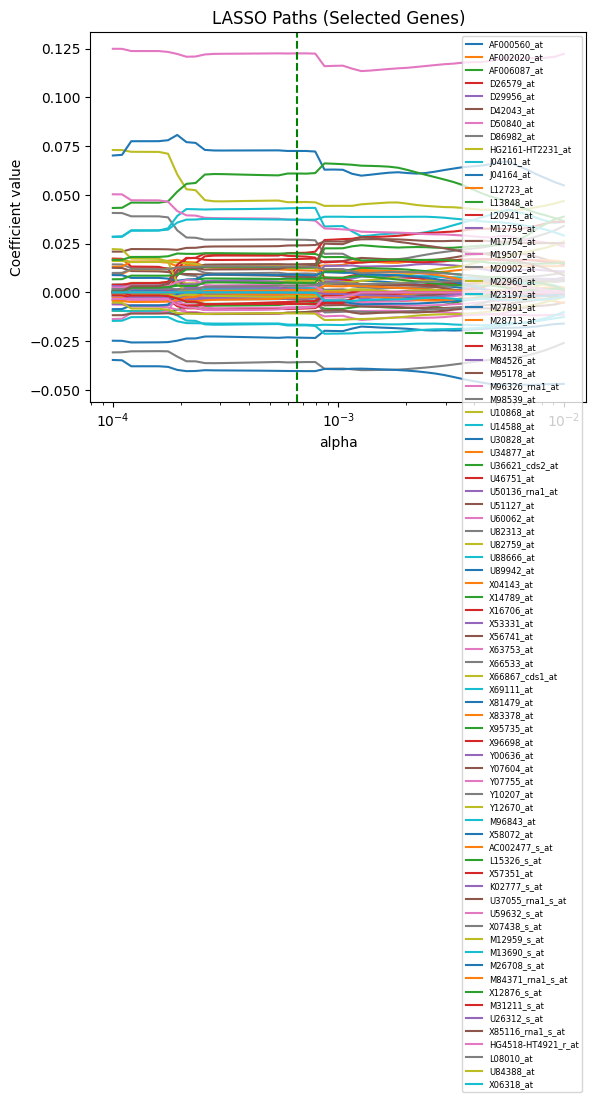

In [3]:
# %%

! git clone https://github.com/ds4e/undergrad_ml_assignments

# 1.

import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/golub.csv')
print(df.head())

mapper = {'allB':0,
          'allT':0,
          'aml':1}

df['outcome'] = df['cancer'].map(mapper)


# %%

# 2. Straight linear regression

mse = lambda y,y_hat : np.mean( (y-y_hat)**2 )

y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer','outcome'],axis=1)

model = LinearRegression()
reg = model.fit(X,y)

y_hat = reg.predict(X)
print(f'OLS training MSE: {mse(y,y_hat)}')

residuals = y_hat - y
sns.kdeplot(residuals)
plt.show()
residuals.describe()

sns.scatterplot(x=y,y=y_hat)
plt.show()

# %%

# 3. Cross validation of the linear model

kfold = KFold(n_splits=5, shuffle=True, random_state=100) # Create folds
scores = cross_val_score( # Conduct kfcv:
    model,X,y, # Model and data
    cv=kfold, # Folds
    scoring='neg_mean_squared_error' # Loss function
)

mse = -scores

sns.histplot(mse,bins=10).set(title='MSE estiamtes')
plt.show()

print("Fold scores:", mse)
print("Mean score:", np.mean(mse))
print("Median score:", np.median(mse))
print("Std dev:", np.std(mse))

"""
The 5-fold cross validation produced a mean MSE of around 0.04. This value is greater
that the training MSE, which suggests that the model is overfitted. The standard
deviation across the fold is large compared to the mean, indicating that the model's
performance is unstable and that there is a high variance across different folds.
These two factors indicate that the model likely has a poor bias-variance, with
very low bias but very high variance, leading to overfitting.
"""

# %%


# 4. Cross-Validated Lasso

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
model = LassoCV(cv=10,
                alphas=alpha_grid,
                random_state=100)
model = model.fit(X_sc, y)

alpha_star = model.alpha_
index_star = np.argmin( np.mean(model.mse_path_,axis=1) )
coefs_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc,y).coef_

selected_idx = np.where(coefs_star != 0)[0]
selected_genes = X.columns[selected_idx]

print("Selected genes:")
print(selected_genes)

y_hat_lasso = model.predict(X_sc)
sns.scatterplot(x=y, y=y_hat_lasso)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("LASSO: Predictions vs Actual")
plt.show()

"""
The cross-validation LASSO model selected genes with non-zero coefficients,
identifying those most predictive of the outcome. In total, 80 genes were selected
and 71299 were discarded.
"""

# %%

# 5. Cross validated MSE versus alpha

sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')
plt.show()

"""
The optimal parameter that minimized expected MSE is α=0.000655. This vale balances
bias and variance, leading to improved generalization performance. Values smaller
than α are overfitted, while values larger than α are underfitted.
"""

# %%

coefs = []
for alpha in model.alphas_: # For each alpha value,
    reg = Lasso(alpha=alpha, max_iter=10_000) # Create a lasso model
    reg = reg.fit(X_sc,y) # Run the regression
    coefs.append(reg.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(model.alphas_, coefs[:, i], label=X.columns[i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

# %%

coefs_star = coefs[index_star]
sns.histplot( coefs_star )
plt.show()

nonzero_indices = np.where( coefs_star != 0 )
#print('Selected Genes:\n', X.columns[nonzero_indices])
sns.histplot( coefs_star[nonzero_indices] )
plt.show()

print("Nonzero coefficients:", np.sum(coefs_star != 0))
print("Total genes:", len(coefs_star))

for i in nonzero_indices:
    plt.plot(model.alphas_, coefs[:, i], label=X.columns[i])

plt.xscale("log")
plt.axvline(alpha_star, linestyle="--", color="green")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Paths (Selected Genes)")
plt.legend(fontsize=6)
plt.show()

6. Linear regression performs perfectly on training data beause there are more genes than observations. This allows the model to effectively memorize the training data, which causes results to be severely overfitted. On the other hand, LASSO adds a L1 regularization penalty that shrinks many coefficients, selecting only a small subset of genes. This provides a better generalization and more accurate predictions on unseen data.

7. Regularization methods are useful in presicion health because orecision health involves highly dimensional data. There are usually thousands of genes but only a few patients. Traditional models tend to overfit due to too many features. Regularization methods like LASSO reduce irrelevant variables and improves model stability.


8. There are a few risks that arises when using LASSO in precision health. LASSO may incorrectly select features, leading to false discoveries. This may also cause instability in the model since small changes in the data can lead to different selected genes. Additionally, if features are highly correlated, LASSO may discard important variables. While LASSO can be a powerful tool, it should be used as a guide and domain experts should be consulted before applying decisions.